In [1]:
import pandas as pd
import numpy as np
from helpers import get_feature_importance
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
from joblib import dump, load

from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_validate 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error as mse, mean_absolute_error as mae, mean_absolute_percentage_error as mape, r2_score
seed = 42

In [10]:
df = pd.read_csv('diamonds.csv')

In [11]:
# удаляем колонку Unnamed: 0 и колонки x,y,z так как они сильно коррелируют с колонкой carat
df.drop(columns=['Unnamed: 0', 'x', 'y', 'z'], inplace=True)

In [12]:
# ====== 1. Разделение на X и y ======
X = df.drop('price', axis=1)
y = df['price']

# ====== 2. Определение типов признаков ======
num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(exclude='number').columns

# ====== 3. Препроцессинг ======
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore')) # handle_unknown='ignore' для исключения ошибки, если в тесте будет новая категория
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# ====== 4. Разбиение ======
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=seed
)

# ====== 5. Модели ======
models = {
    'LinearcRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(random_state=seed),
    'XGBoost': XGBRegressor(random_state=seed)
}

# ====== 6. Кросс-валидация ======
scoring = ['r2', 'neg_mean_squared_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_root_mean_squared_error']

cv = KFold(n_splits=5, shuffle=True, random_state=seed) 

cross_val_res = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    
    cross_val={}
    for metric in scoring:
        mean_score = abs(cv_results[f'test_{metric}'].mean())
        std_score = abs(cv_results[f'test_{metric}'].std())
        cross_val[metric] = round(mean_score, 4)
    cross_val_res[name] = cross_val

result_cross_val = pd.DataFrame(cross_val_res).T
result_cross_val.rename(columns={'neg_mean_squared_error': 'mse', 
                                 'neg_mean_absolute_error': 'mae', 
                                 'neg_mean_absolute_percentage_error':'mape', 
                                 'neg_root_mean_squared_error':'rmse'}, inplace=True)

#====== 7. Финальное обучение и тест ======
list_of_models=[]
results={}
for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipeline.fit(X_train, y_train)
    list_of_models.append(pipeline)
    y_pred = pipeline.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse_score = mse(y_test, y_pred)
    mae_score = mae(y_test, y_pred)
    mape_score = mape(y_test, y_pred)
    rmse_score = np.sqrt(mse(y_test, y_pred))
    results[name] = [r2, mse_score, mae_score, mape_score, rmse_score]

result_test = pd.DataFrame(results, index=['r2', 'mse', 'mae', 'mape', 'rmse']).T

In [13]:
print('')
print('Результаты на кросс-валидации')
print('')
display(result_cross_val)
print('')
print('Результаты на тестовой выборке')
print('')
display(result_test)


Результаты на кросс-валидации



,r2,mse,mae,mape,rmse
LinearcRegression,0.9160,1.337345e+06,805.7307,0.4493,1156.1449
RandomForest,0.9754,3.916307e+05,308.9355,0.0877,625.6718
XGBoost,0.9781,3.489615e+05,300.5996,0.0841,590.6448



Результаты на тестовой выборке



,r2,mse,mae,mape,rmse
LinearcRegression,0.915411,1.344704e+06,801.559543,0.454758,1159.613699
RandomForest,0.976138,3.793341e+05,301.160026,0.087000,615.901036
XGBoost,0.978765,3.375764e+05,295.337585,0.083433,581.013231


## Коэффициенты модели логистической регресии и важности признаков по RandomForest и XGBoost

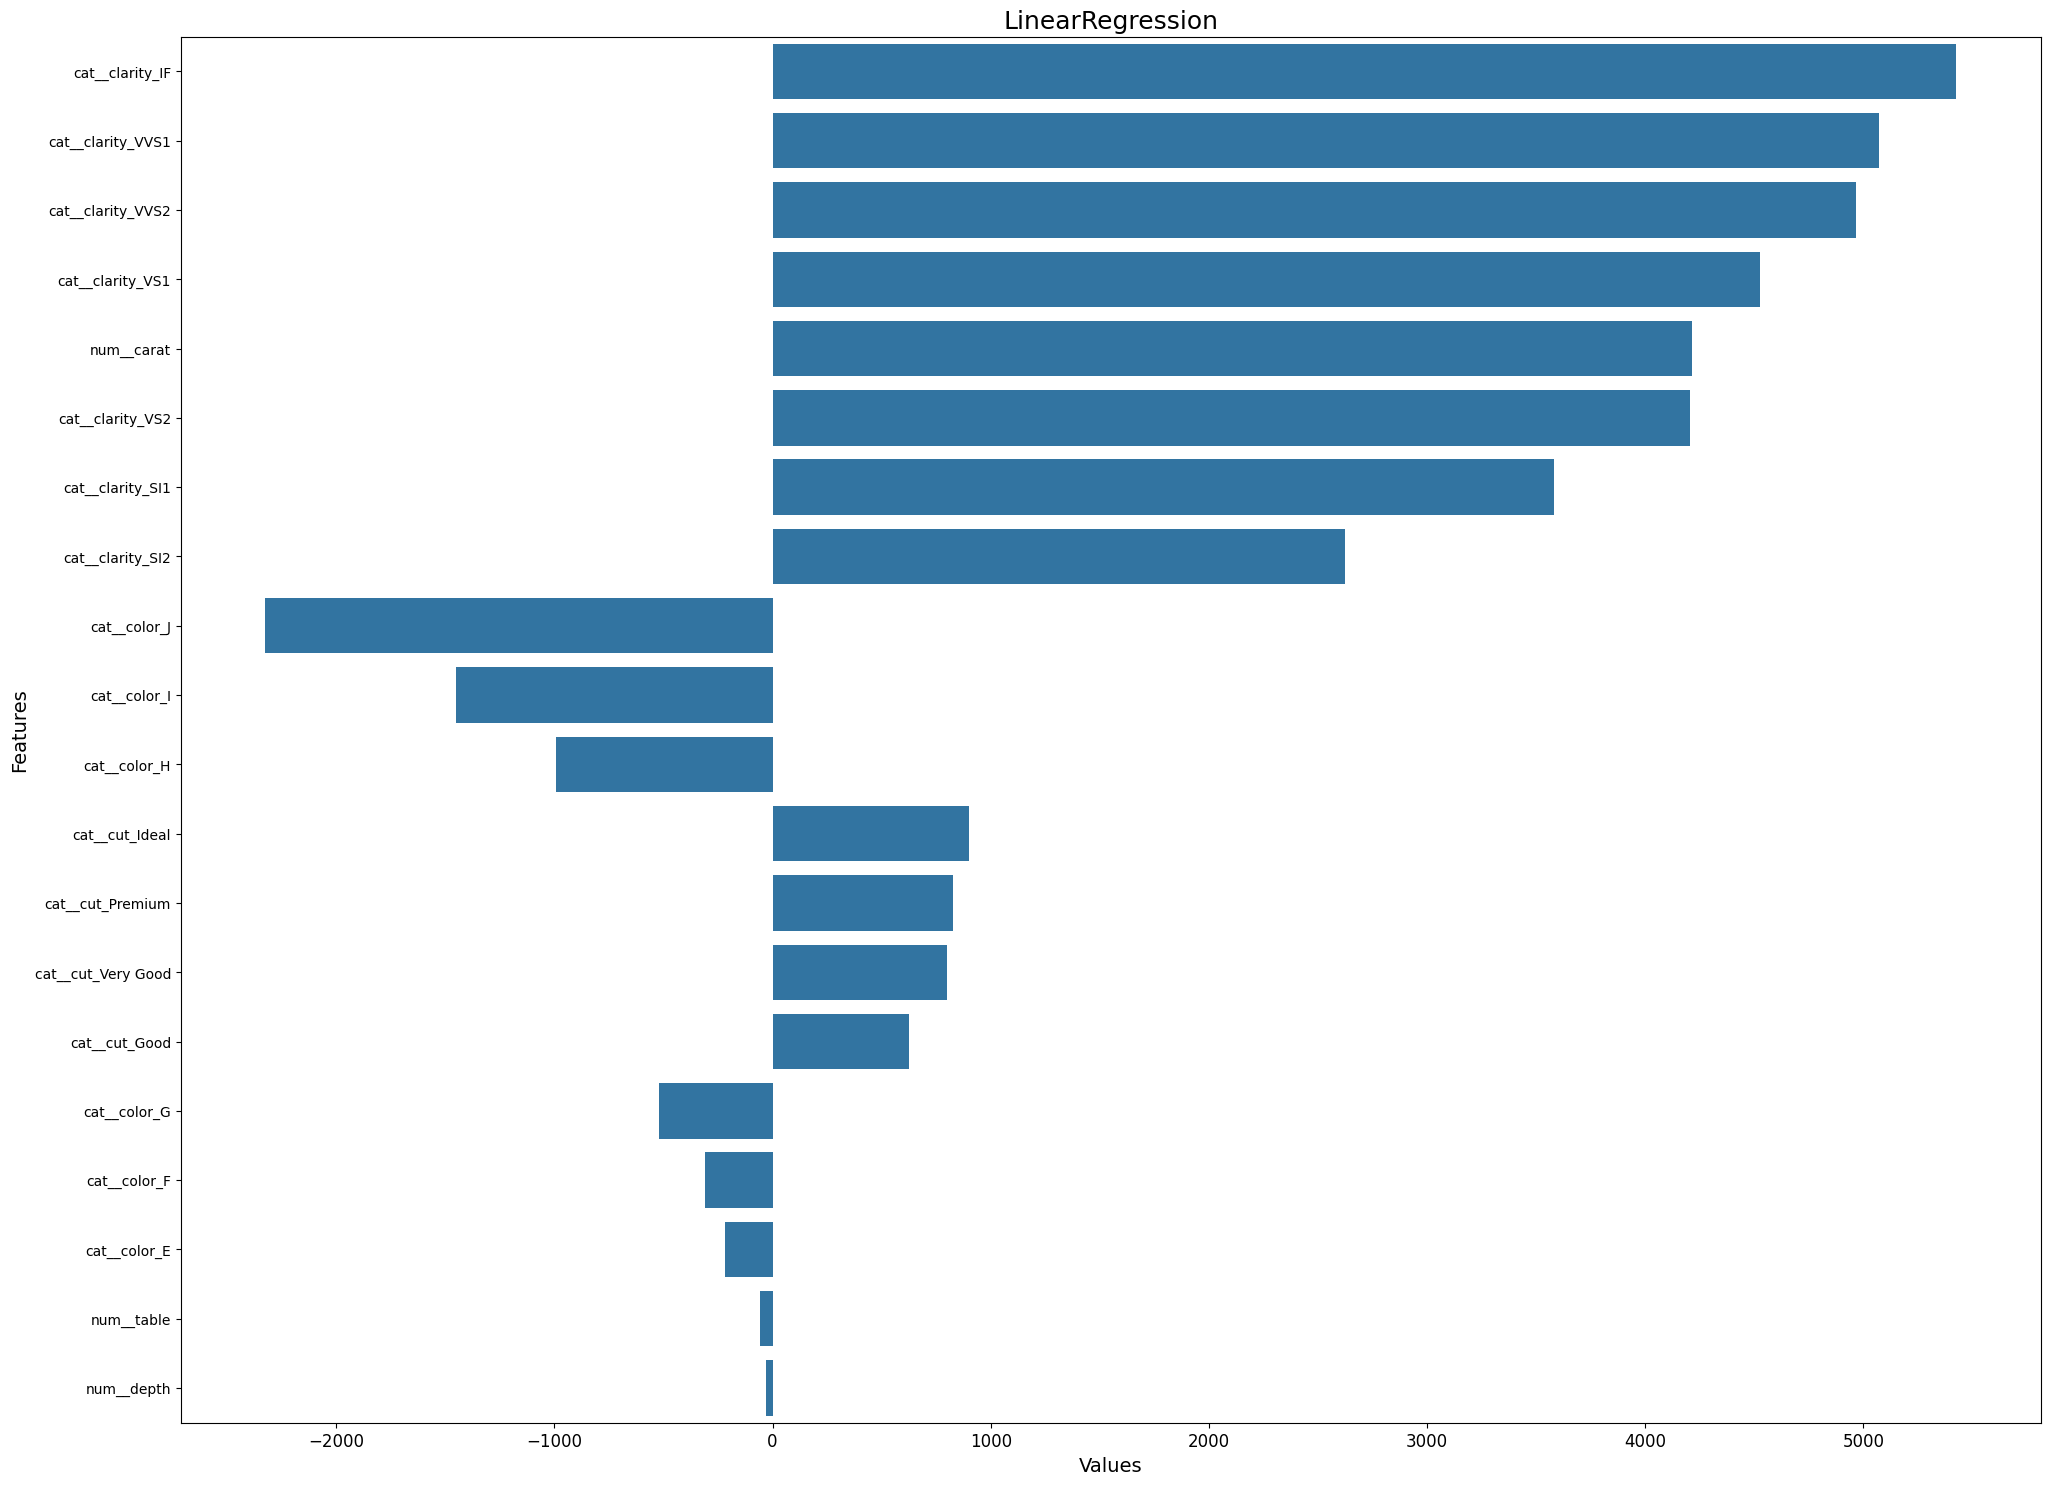

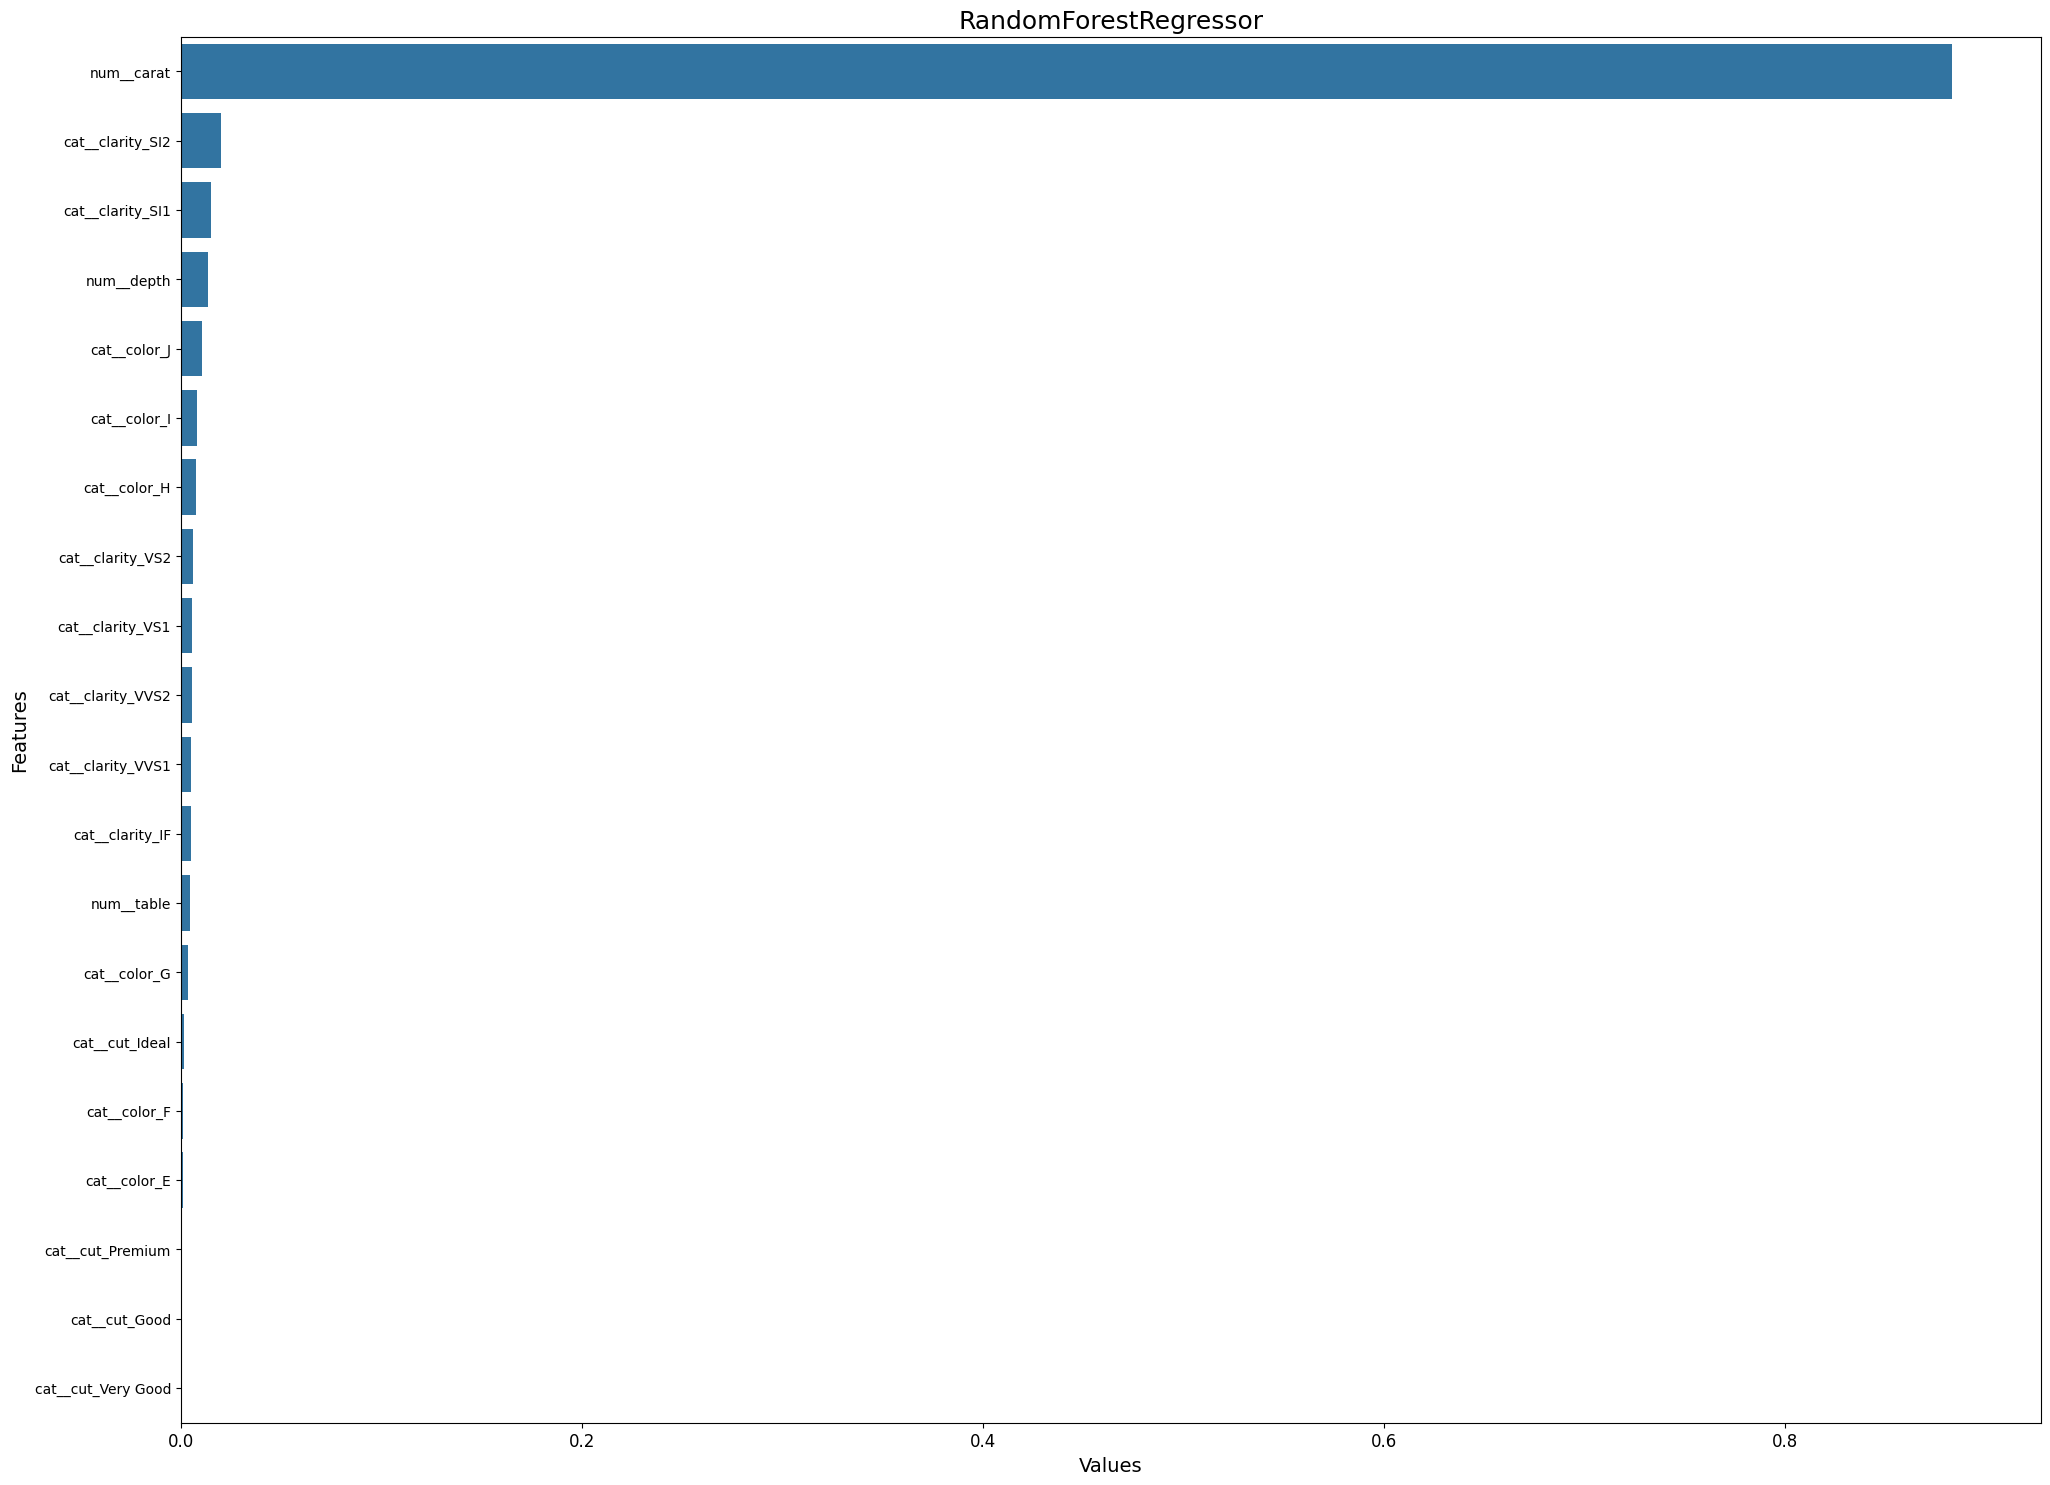

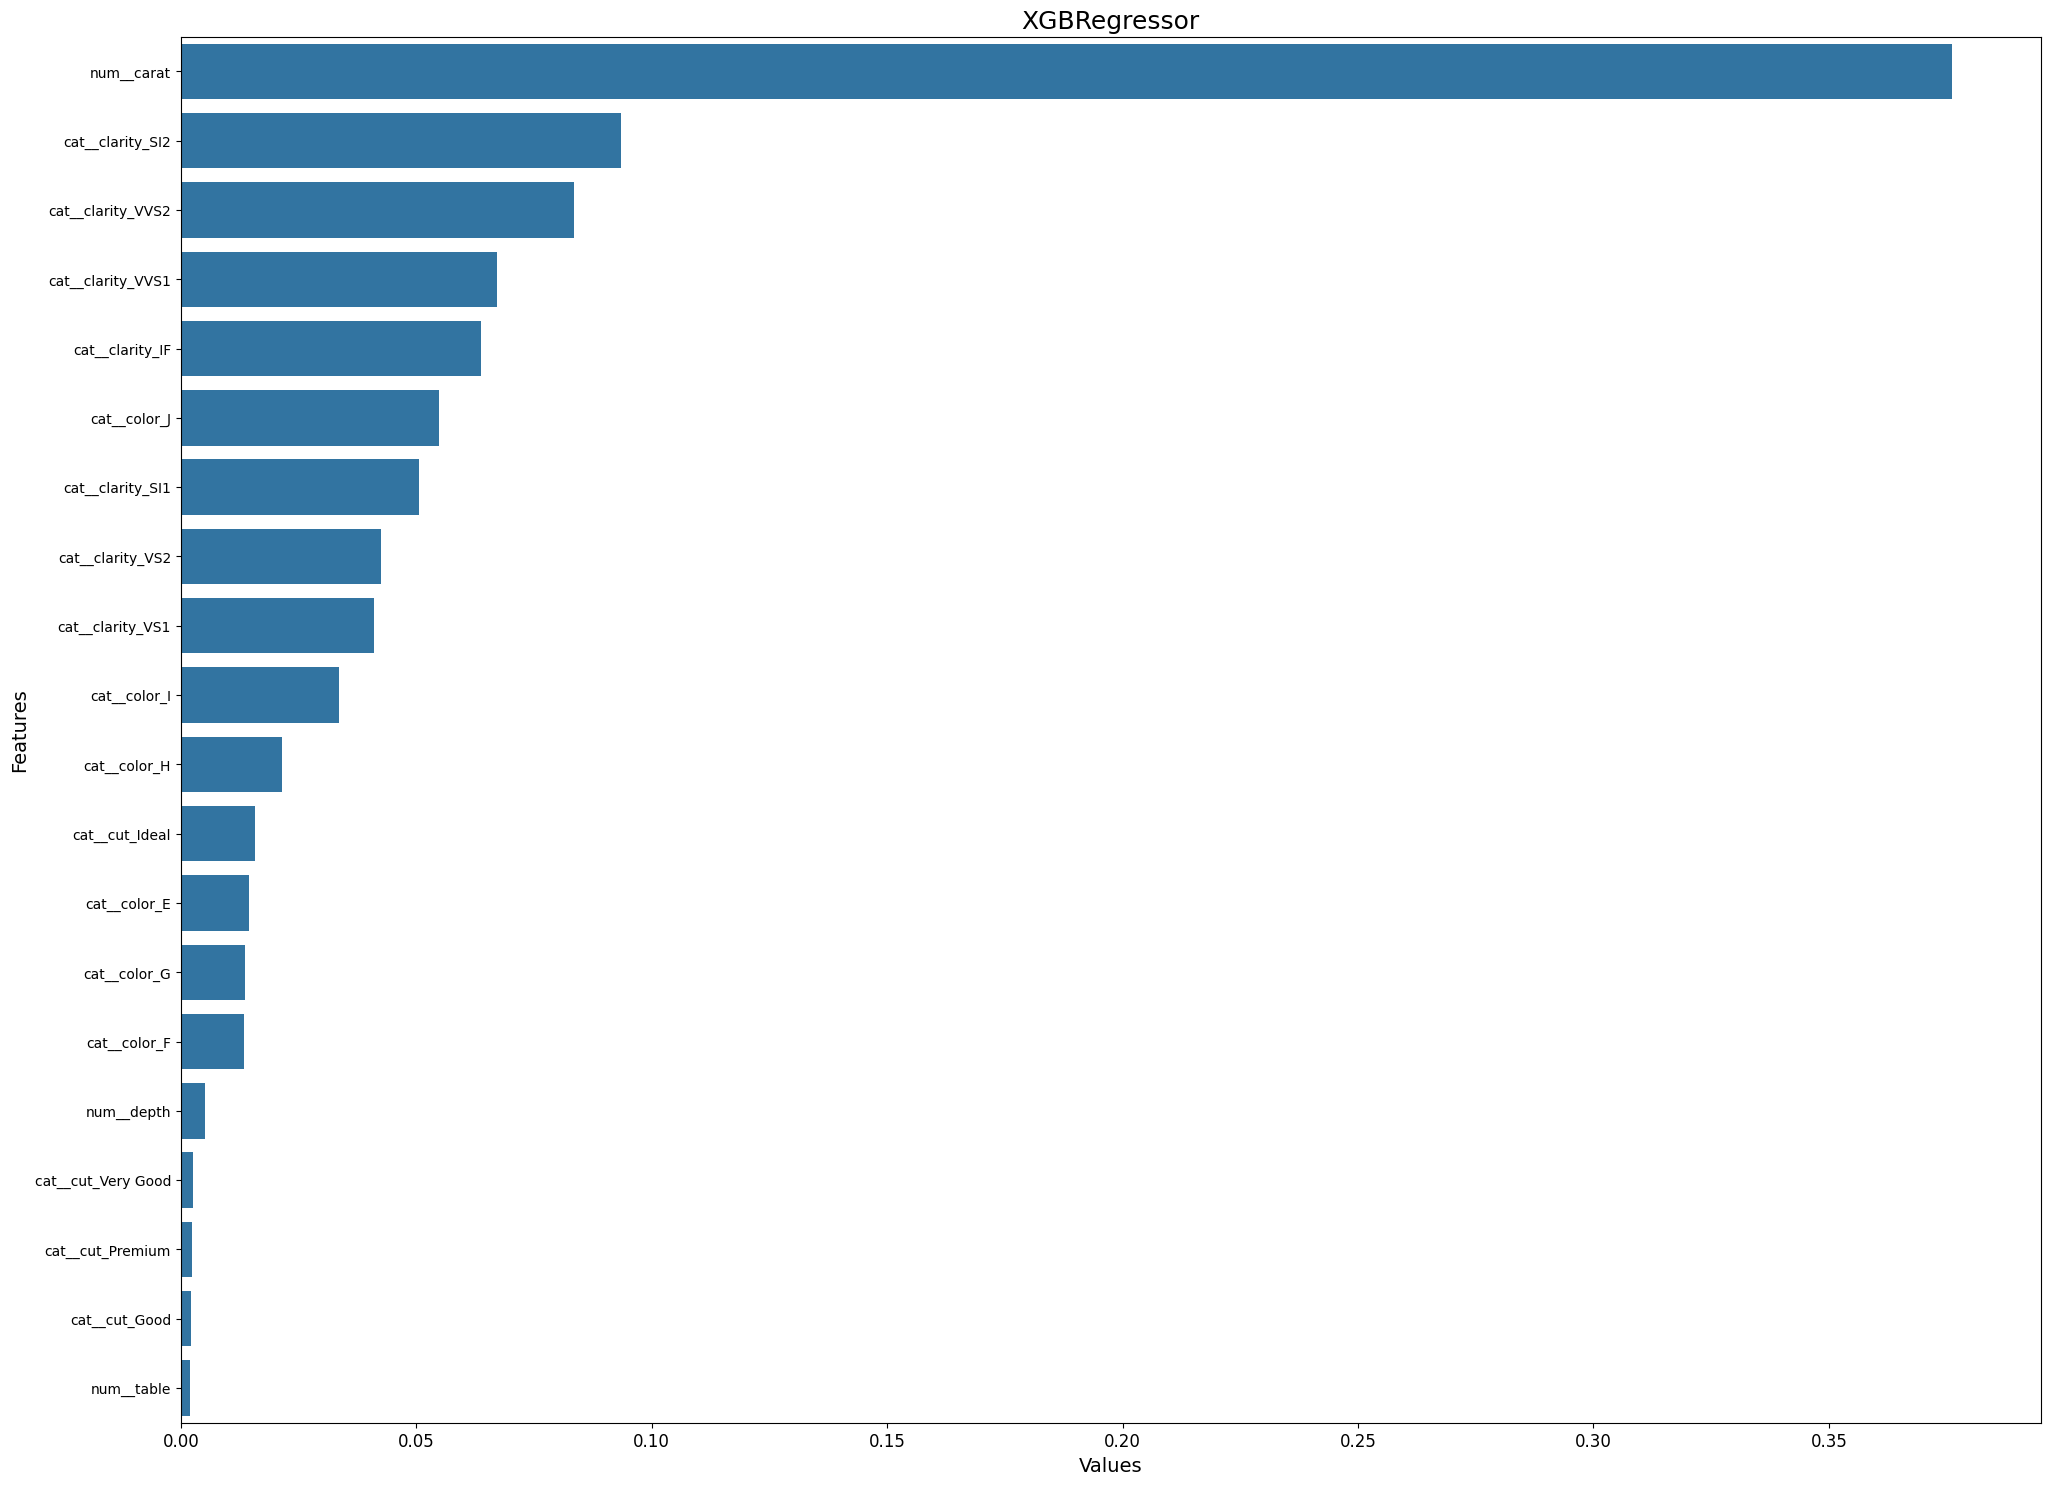

In [6]:
get_feature_importance(list_of_models)

In [14]:
# сохраним результаты по модели XGBoost для дальнейшей работы
dump(result_cross_val.iloc[[2]], 'result_cross_val_baseline_v2.joblib')
dump(result_test.iloc[[2]], 'result_test_baseline_v2.joblib')

['result_test_baseline_v2.joblib']

## Результаты 

По результатам видно, что линейная регрессия показала гораздо худшие результаты по сравнению с RandomForest и XGBoost. Особенно бросается в галаза метрика mape, которая примерно в 5 раз хуже, по сравнению с RandomForest и XGBoost. 

Метрикии RandomForest и XGBoost досточно близки, но тем не менее метрики XGBoost немного лучше. Также анализ важности признаков говорит о том, что в RandomForest практически только один признак (carat) имеет важность, остальные - практически зануляются, при этом в XGBoost распределение более гладкое. Поэтому для следующих этапов возьмем модель XGBoost в качестве основы.